#### Reference Hamiltonian

#### Import

In [138]:
import numpy as np
import json
import matplotlib.pyplot as plt
from src.interaction_utils import EffectiveInteractionOptimizer
from ManyBodyQutip.qutip_class import SpinOperator, SpinHamiltonian
import qutip as qt
from src.utils import computational_basis
from qutip import fidelity
from NSMFermions.hamiltonian_utils import FermiHubbardHamiltonian
from NSMFermions.nuclear_physics_utils import (
    get_twobody_nuclearshell_model,
    SingleParticleState,
)
import numpy as np
import torch
from typing import Dict
import scipy
from NSMFermions.qml_models import AdaptVQEFermiHubbard
from NSMFermions.qml_utils.train import Fit
from NSMFermions.qml_utils.utils import configuration
from scipy.sparse.linalg import eigsh, expm_multiply
from tqdm import trange
import matplotlib.pyplot as plt
from NSMFermions.utils_quasiparticle_approximation import (
    QuasiParticlesConverter,
    HardcoreBosonsBasis,
    QuasiParticlesConverterOnlynnpp,
)
from src.utils import generate_particleconservation_basis, array_to_qutip

##### Parameters

In [193]:
data_onebody = np.load("data/matrix_elements_h_eff_2body/one_body_nn_pf.npz")
keys = data_onebody["keys"]
values = data_onebody["values"]
logical_qubits = 10

g_onebody = {}
diagonal_elements = np.zeros(logical_qubits)
g_matrix = np.zeros((logical_qubits, logical_qubits))
for a, key in enumerate(keys):
    i, j = key
    if i != j:
        g_matrix[i, j] = values[a]
    if i == j:
        diagonal_elements[i] = values[a]


# get the computational basis of the space
basis = computational_basis(logical_qubits)

In [194]:
hamiltonian_xy = 0.0
for i in range(logical_qubits):
    for j in range(i + 1, logical_qubits):
        hamiltonian_xy += SpinOperator(
            [("x", i, "x", j)],
            coupling=[0.5 * g_matrix[i, j]],
            size=logical_qubits,
            verbose=1,
        ).qutip_op
        hamiltonian_xy += SpinOperator(
            [("y", i, "y", j)],
            coupling=[0.5 * g_matrix[i, j]],
            size=logical_qubits,
            verbose=1,
        ).qutip_op
hamiltonian_z = 0.0
for i in range(logical_qubits):
    hamiltonian_z += SpinOperator(
        [("qz", i)], coupling=[diagonal_elements[i]], size=logical_qubits, verbose=1
    ).qutip_op
nsm_quasiparticle_hamiltonian = hamiltonian_z + hamiltonian_xy

In [195]:
eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

In [196]:
import numpy as np
from src.utils import computational_basis
import qutip as qt

# or just set n_qubits directly if you know it

N_op = sum(
    SpinOperator([("qz", i)], coupling=[1], size=logical_qubits).qutip_op
    for i in range(logical_qubits)
)
print(N_op.shape)

# shape (2**logical_qubits, logical_qubits)

# --- get all eigenstates ---
eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

# Get all eigenstates
eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

# Filter by <psi|N|psi> == 1
N_target = 1
sector_indices = [
    i
    for i, psi in enumerate(eigenstates_nsm)
    if abs(qt.expect(N_op, psi) - N_target) < 1e-6
]

eigenvalues_N1 = eigenvalues_nsm[sector_indices]
eigenstates_N1 = [eigenstates_nsm[i] for i in sector_indices]

# Lowest energy state in the N=1 sector
idx = sector_indices[np.argmin(eigenvalues_nsm[sector_indices])]
ground_state_N1 = eigenstates_nsm[idx]
ground_eigenvalue_N1 = eigenvalues_nsm[idx]

print("Ground state energy in N=1 sector:", ground_eigenvalue_N1)
print("Ground state in N=1 sector (in computational basis):")

(1024, 1024)
Ground state energy in N=1 sector: -19.733675784796766
Ground state in N=1 sector (in computational basis):



   Bitstring    |amp|^2    Re(amp)    Im(amp)
----------------------------------------------
  0000000001    0.00264   -0.05134    0.00000
  0000000010    0.00316   -0.05624    0.00000
  0000000100    0.00316    0.05624    0.00000
  0000001000    0.00316   -0.05624    0.00000
  0000010000    0.00778    0.08820    0.00000
  0000100000    0.00778   -0.08820    0.00000
  0001000000    0.24308    0.49303    0.00000
  0010000000    0.24308   -0.49303    0.00000
  0100000000    0.24308    0.49303    0.00000
  1000000000    0.24308   -0.49303    0.00000


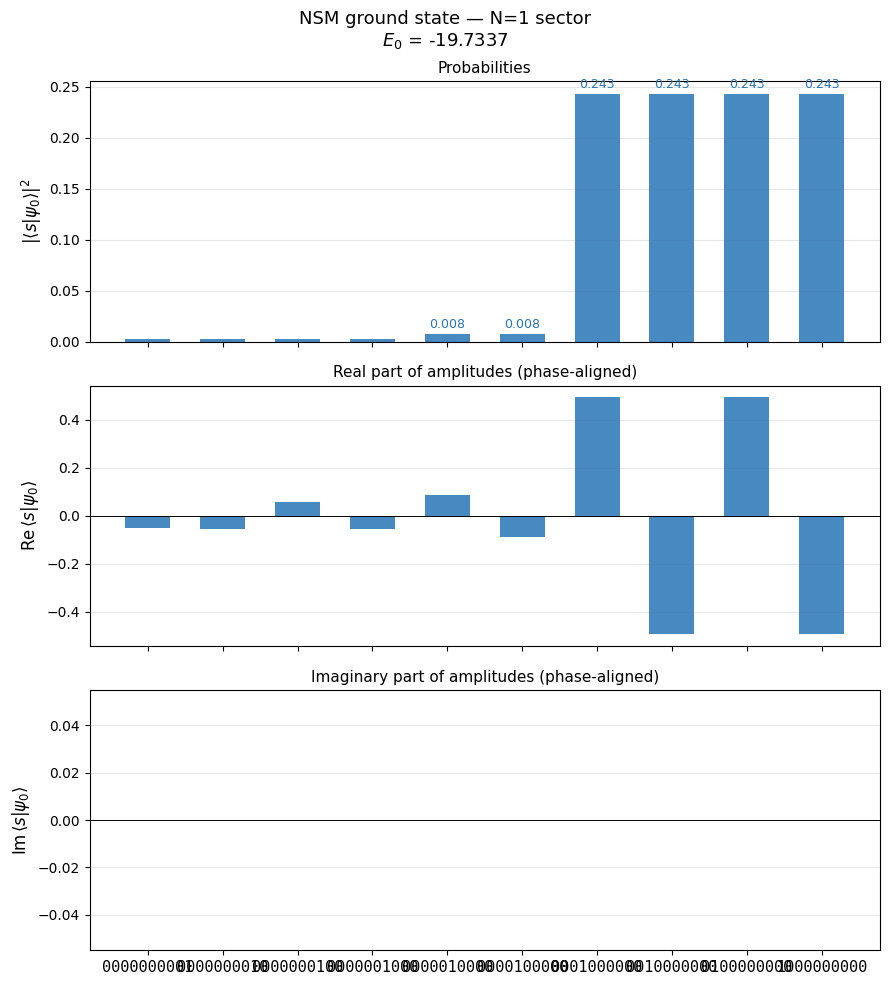

In [197]:
import matplotlib.pyplot as plt

# ── Amplitudes and probabilities of the NSM N=1 ground state ─────────────────

amps = ground_state_N1.full().flatten()  # complex amplitudes

# Phase-align: rotate so largest component is real+positive
idx_max = np.argmax(np.abs(amps))
amps_aligned = amps * np.exp(-1j * np.angle(amps[idx_max]))

probs = np.abs(amps_aligned) ** 2
re = amps_aligned.real
im = amps_aligned.imag

# Keep only N=1 sector bitstrings for plotting
basis_labels = ["".join(map(str, row)) for row in computational_basis(logical_qubits)]
n1_mask = np.array([sum(int(b) for b in lbl) == 1 for lbl in basis_labels])
labels_n1 = [l for l, m in zip(basis_labels, n1_mask) if m]

probs_n1 = probs[n1_mask]
re_n1 = re[n1_mask]
im_n1 = im[n1_mask]

# Print table
print(f"\n{'Bitstring':>12}  {'|amp|^2':>9}  {'Re(amp)':>9}  {'Im(amp)':>9}")
print("-" * 46)
for lbl, p, r, i_ in zip(labels_n1, probs_n1, re_n1, im_n1):
    print(f"{lbl:>12}  {p:>9.5f}  {r:>9.5f}  {i_:>9.5f}")

# ── Three-panel plot ──────────────────────────────────────────────────────────
CLR = "#2775b6"
x = np.arange(len(labels_n1))
width = 0.6

fig, axes = plt.subplots(3, 1, figsize=(max(6, len(labels_n1) * 0.9), 10), sharex=True)
fig.suptitle(
    f"NSM ground state — N=1 sector\n" f"$E_0$ = {ground_eigenvalue_N1:.4f}",
    fontsize=13,
)

# Panel 1: probabilities
ax = axes[0]
bars = ax.bar(x, probs_n1, width, color=CLR, alpha=0.85)
ax.set_ylabel(r"$|\langle s|\psi_0\rangle|^2$", fontsize=12)
ax.set_title("Probabilities", fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
for bar, v in zip(bars, probs_n1):
    if v > 0.005:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + 0.003,
            f"{v:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color=CLR,
        )

# Panel 2: real parts
ax = axes[1]
bars = ax.bar(x, re_n1, width, color=CLR, alpha=0.85)
ax.axhline(0, color="k", linewidth=0.7)
ax.set_ylabel(r"$\mathrm{Re}\,\langle s|\psi_0\rangle$", fontsize=12)
ax.set_title("Real part of amplitudes (phase-aligned)", fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

# Panel 3: imaginary parts
ax = axes[2]
bars = ax.bar(x, im_n1, width, color=CLR, alpha=0.85)
ax.axhline(0, color="k", linewidth=0.7)
ax.set_ylabel(r"$\mathrm{Im}\,\langle s|\psi_0\rangle$", fontsize=12)
ax.set_title("Imaginary part of amplitudes (phase-aligned)", fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(labels_n1, fontfamily="monospace", fontsize=11)

plt.tight_layout()
plt.savefig("nsm_gs_wavefunction.pdf", bbox_inches="tight")
plt.show()

#### Getting the freaking effective Interaction

Optimal drive parameters: [-0.50700705  0.59487242 -0.6160578   0.56638526 -0.75691226  0.76236622
 -0.57893056  0.61455154 -0.59645235 -0.66705995]
Optimized effective interaction matrix:
 [[ 0.         -0.30820458 -0.01433202  0.08015223 -0.02097418  0.24203233
   0.22939234 -0.05311     0.0078746  -0.1482041 ]
 [-0.30820458  0.         -0.27103459  0.06509186  0.18103467 -0.21546379
  -0.06550851  0.04994316 -0.01765204  0.20681557]
 [-0.01433202 -0.27103459  0.         -0.4612129  -0.25943956  0.1692454
  -0.01033871 -0.03552623  0.06999574 -0.22094749]
 [ 0.08015223  0.06509186 -0.4612129   0.          0.25302652 -0.10019203
   0.00984447  0.05476844 -0.13916987  0.18781293]
 [-0.02097418  0.18103467 -0.25943956  0.25302652  0.          0.06314434
   0.03113059 -0.05123823  0.08847253  0.55066314]
 [ 0.24203233 -0.21546379  0.1692454  -0.10019203  0.06314434  0.
  -0.10642246  0.03219662 -0.02246004 -0.54702502]
 [ 0.22939234 -0.06550851 -0.01033871  0.00984447  0.03113059 -0.1064

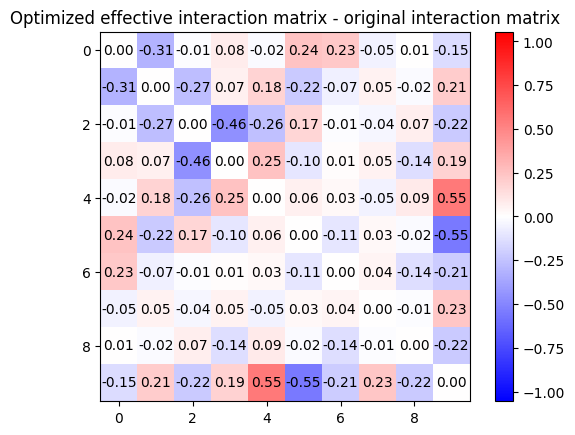

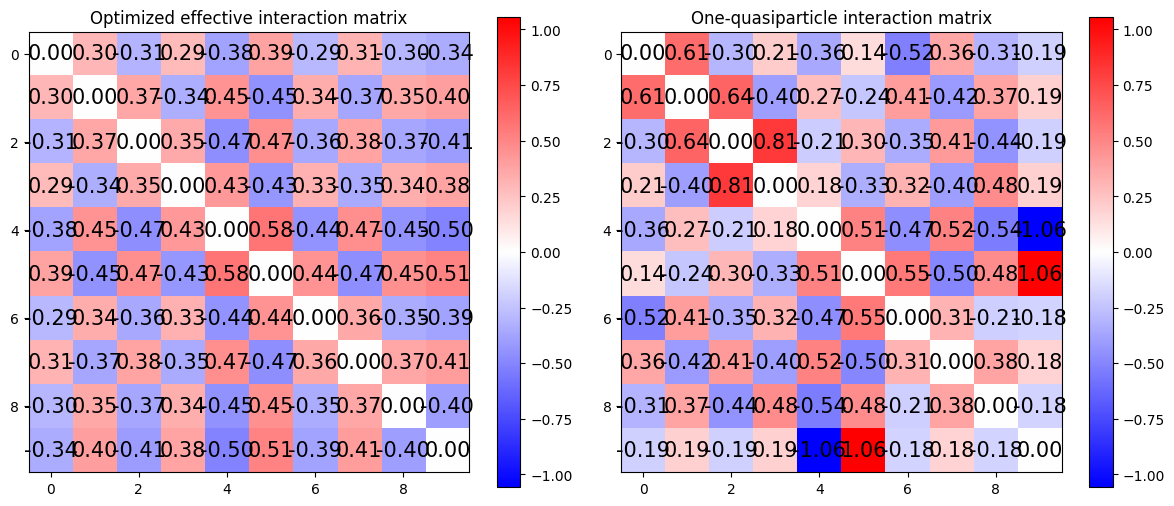

In [198]:
OptimalFieldBe6 = EffectiveInteractionOptimizer(
    nqubit=logical_qubits, n_restarts=100, scale=2.0, ftol=1e-15, gtol=1e-10
)

d_opt, result = OptimalFieldBe6.optimize_rank1(g_matrix)
print("Optimal drive parameters:", d_opt)
print(
    "Optimized effective interaction matrix:\n",
    OptimalFieldBe6.reconstructed(d_opt) - g_matrix,
)
plt.imshow(
    OptimalFieldBe6.reconstructed(d_opt) - g_matrix,
    cmap="bwr",
    vmin=-np.max(np.abs(g_matrix)),
    vmax=np.max(np.abs(g_matrix)),
)
for i in range(logical_qubits):
    for j in range(logical_qubits):
        plt.text(
            j,
            i,
            f"{OptimalFieldBe6.reconstructed(d_opt)[i,j]-g_matrix[i,j]:.2f}",
            ha="center",
            va="center",
            color="black",
        )
plt.colorbar()
plt.title("Optimized effective interaction matrix - original interaction matrix")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

vmax = np.max(np.abs(g_matrix))
matrices = [OptimalFieldBe6.reconstructed(d_opt), g_matrix]
titles = [
    "Optimized effective interaction matrix",
    "One-quasiparticle interaction matrix",
]

for ax, mat, title in zip(axes, matrices, titles):
    im = ax.imshow(mat, cmap="bwr", vmin=-vmax, vmax=vmax)
    for i in range(logical_qubits):
        for j in range(logical_qubits):
            ax.text(
                j,
                i,
                f"{mat[i,j]:.2f}",
                ha="center",
                va="center",
                color="black",
                fontsize=15,
            )
    plt.colorbar(im, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

#### D-WAVE Embedding and effective Hamiltonians

In [177]:
import minorminer
import dwave_networkx as dnx
import networkx as nx

# K4: fully connected, 4 nodes = 6 edges
K4 = nx.complete_graph(logical_qubits)
print("Problem edges:", list(K4.edges()))

# Hardware graph
hardware = dnx.pegasus_graph(16)

import minorminer

embedding = minorminer.find_embedding(K4, hardware)


# Manual verification
def check_embedding(embedding, problem_graph, hardware_graph):
    # Check 1: all chains connected in hardware
    for node, chain in embedding.items():
        subgraph = hardware_graph.subgraph(chain)
        if not nx.is_connected(subgraph):
            print(f"✗ q{node}: chain {chain} is NOT connected in hardware")
            return False

    # Check 2: every problem edge has a coupler between chains
    for u, v in problem_graph.edges():
        chain_u = set(embedding[u])
        chain_v = set(embedding[v])
        has_coupler = any(
            hardware_graph.has_edge(a, b) for a in chain_u for b in chain_v
        )
        if not has_coupler:
            print(
                f"✗ edge ({u},{v}): no coupler between chains {chain_u} and {chain_v}"
            )
            return False

    print("✓ Valid embedding")
    print(f"  Chain lengths: { {f'q{k}': len(v) for k,v in embedding.items()} }")
    return True


check_embedding(embedding, K4, hardware)

Problem edges: [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 9), (4, 5), (4, 6), (4, 7), (4, 8), (4, 9), (5, 6), (5, 7), (5, 8), (5, 9), (6, 7), (6, 8), (6, 9), (7, 8), (7, 9), (8, 9)]
✓ Valid embedding
  Chain lengths: {'q0': 1, 'q1': 1, 'q2': 2, 'q3': 2, 'q4': 2, 'q5': 1, 'q6': 1, 'q7': 2, 'q8': 2, 'q9': 2}


True

/tmp/ipykernel_21508/2518061446.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


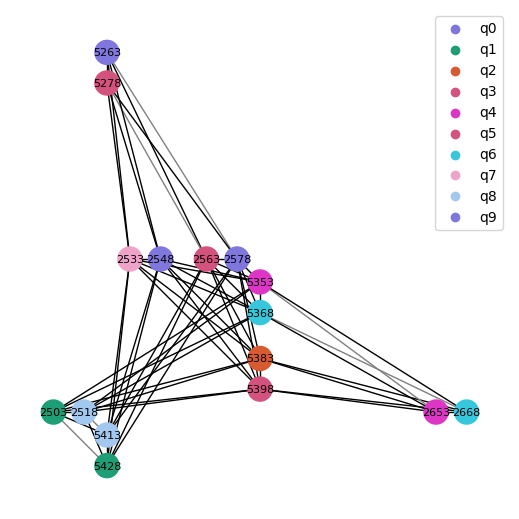

In [181]:
import matplotlib.pyplot as plt
import dwave_networkx as dnx
import minorminer
import networkx as nx

K4 = nx.complete_graph(logical_qubits)
hardware = dnx.pegasus_graph(16)
embedding = minorminer.find_embedding(K4, hardware)

# Extract only the hardware nodes/edges used
used_nodes = [node for chain in embedding.values() for node in chain]
used_edges = []
for u, v in K4.edges():
    for a in embedding[u]:
        for b in embedding[v]:
            if hardware.has_edge(a, b):
                used_edges.append((a, b))

# Color by logical qubit
colors = [
    "#7F77DD",
    "#1D9E75",
    "#D85A30",
    "#D4537E",
    "#DD36C7",
    "#D4537E",
    "#36C7DD",
    "#F0A3C8",
    "#A3C8F0",
    "#7F77DD",
    "#CFD49D",
]  # purple, teal, coral, pink
node_colors = {}
for i, chain in embedding.items():
    for node in chain:
        node_colors[node] = colors[i]

subgraph = hardware.subgraph(used_nodes).copy()
for u, v in used_edges:
    if not subgraph.has_edge(u, v):
        subgraph.add_edge(u, v)

pos = dnx.pegasus_layout(subgraph)

plt.figure(figsize=(5, 5))
nx.draw(
    subgraph,
    pos,
    node_color=[node_colors[n] for n in subgraph.nodes()],
    edge_color=[
        "gray" if (u, v) not in used_edges and (v, u) not in used_edges else "black"
        for u, v in subgraph.edges()
    ],
    node_size=300,
    with_labels=True,
    font_size=8,
)
plt.legend(
    handles=[
        plt.scatter([], [], c=colors[i], label=f"q{i}") for i in range(logical_qubits)
    ]
)
plt.tight_layout()
plt.savefig("embedding.png", dpi=150)
plt.show()

In [182]:
print(used_nodes)
print(used_edges)

# build index map: physical qubit → local index 0..7
phys_to_idx = {phys: idx for idx, phys in enumerate(used_nodes)}

print("=== Physical → Local index ===")
for phys, idx in phys_to_idx.items():
    print(f"  {phys} → {idx}")

print("\n=== Chains (local indices) ===")
mapping = []
for logical, chain in embedding.items():
    local_chain = [phys_to_idx[p] for p in chain]
    mapping.append(local_chain)
    print(f"  q{logical} → {local_chain}")

print("\n=== Edges (local indices) ===")
local_edges = [(phys_to_idx[u], phys_to_idx[v]) for u, v in used_edges]
print(local_edges)

[2548, 5428, 2503, 5383, 5278, 2563, 2653, 5353, 5398, 2668, 5368, 2533, 5413, 2518, 5263, 2578]
[(2548, 5428), (2548, 5383), (2548, 5278), (2548, 5353), (2548, 5398), (2548, 5368), (2548, 2533), (2548, 5413), (2548, 5263), (2503, 5383), (5428, 2563), (2503, 5353), (2503, 5398), (2503, 5368), (5428, 2533), (5428, 5413), (5428, 2518), (2503, 5413), (2503, 2518), (5428, 2578), (5383, 2563), (5383, 2653), (5383, 5398), (5383, 2668), (5383, 2533), (5383, 2518), (5383, 2578), (2563, 5353), (2563, 5398), (2563, 5368), (5278, 2533), (2563, 5413), (5278, 5263), (5278, 2578), (2563, 5263), (2563, 2578), (2653, 5398), (2653, 2668), (2653, 5368), (5353, 2668), (5353, 5368), (5353, 2533), (5353, 2518), (5353, 2578), (5398, 2668), (5398, 2533), (5398, 2518), (5398, 2578), (5368, 2533), (5368, 2518), (5368, 2578), (2533, 5413), (2533, 5263), (5413, 2578)]
=== Physical → Local index ===
  2548 → 0
  5428 → 1
  2503 → 2
  5383 → 3
  5278 → 4
  2563 → 5
  2653 → 6
  5353 → 7
  5398 → 8
  2668 → 9
  536

Encoding

In [183]:
# chains dict: already comes from embedding + phys_to_idx
chains = {
    logical: [phys_to_idx[p] for p in chain] for logical, chain in embedding.items()
}

# intra_edges: pairs within the same chain that are connected in hardware
intra_edges = []
for logical, chain in chains.items():
    local_chain = [phys_to_idx[p] for p in embedding[logical]]
    for k in range(len(local_chain) - 1):
        intra_edges.append((local_chain[k], local_chain[k + 1]))

# inter_edges: all local_edges minus intra_edges
intra_set = set(map(frozenset, intra_edges))
inter_edges = [(u, v) for u, v in local_edges if frozenset((u, v)) not in intra_set]

print("Chains:", chains)
print("Intra edges:", intra_edges)
print("Inter edges:", inter_edges)
print("Representatives:", {l: chain[0] for l, chain in chains.items()})

Chains: {0: [0], 1: [1, 2], 2: [3], 3: [4, 5], 4: [6, 7], 5: [8], 6: [9, 10], 7: [11], 8: [12, 13], 9: [14, 15]}
Intra edges: [(1, 2), (4, 5), (6, 7), (9, 10), (12, 13), (14, 15)]
Inter edges: [(0, 1), (0, 3), (0, 4), (0, 7), (0, 8), (0, 10), (0, 11), (0, 12), (0, 14), (2, 3), (1, 5), (2, 7), (2, 8), (2, 10), (1, 11), (1, 12), (1, 13), (2, 12), (2, 13), (1, 15), (3, 5), (3, 6), (3, 8), (3, 9), (3, 11), (3, 13), (3, 15), (5, 7), (5, 8), (5, 10), (4, 11), (5, 12), (4, 14), (4, 15), (5, 14), (5, 15), (6, 8), (6, 9), (6, 10), (7, 9), (7, 10), (7, 11), (7, 13), (7, 15), (8, 9), (8, 11), (8, 13), (8, 15), (10, 11), (10, 13), (10, 15), (11, 12), (11, 14), (12, 15)]
Representatives: {0: 0, 1: 1, 2: 3, 3: 4, 4: 6, 5: 8, 6: 9, 7: 11, 8: 12, 9: 14}


In [184]:
# physical qubit -> logical qubit lookup
phys_to_logical = {}
for logical, chain in chains.items():
    for p in chain:
        phys_to_logical[p] = logical

In [185]:
# for each logical pair, find the physical coupler
logical_pair_to_physical_coupler = {}
for u, v in inter_edges:
    lu = phys_to_logical[u]
    lv = phys_to_logical[v]
    if lu == lv:
        continue
    pair = frozenset((lu, lv))
    if pair not in logical_pair_to_physical_coupler:
        logical_pair_to_physical_coupler[pair] = (u, v)

print("=== Logical pair → physical coupler ===")
for pair, (u, v) in logical_pair_to_physical_coupler.items():
    lu, lv = tuple(pair)
    print(f"  q{lu}-q{lv}: physical ({u},{v})")

=== Logical pair → physical coupler ===
  q0-q1: physical (0,1)
  q0-q2: physical (0,3)
  q0-q3: physical (0,4)
  q0-q4: physical (0,7)
  q0-q5: physical (0,8)
  q0-q6: physical (0,10)
  q0-q7: physical (0,11)
  q0-q8: physical (0,12)
  q0-q9: physical (0,14)
  q1-q2: physical (2,3)
  q1-q3: physical (1,5)
  q1-q4: physical (2,7)
  q1-q5: physical (2,8)
  q1-q6: physical (2,10)
  q1-q7: physical (1,11)
  q8-q1: physical (1,12)
  q1-q9: physical (1,15)
  q2-q3: physical (3,5)
  q2-q4: physical (3,6)
  q2-q5: physical (3,8)
  q2-q6: physical (3,9)
  q2-q7: physical (3,11)
  q8-q2: physical (3,13)
  q9-q2: physical (3,15)
  q3-q4: physical (5,7)
  q3-q5: physical (5,8)
  q3-q6: physical (5,10)
  q3-q7: physical (4,11)
  q8-q3: physical (5,12)
  q9-q3: physical (4,14)
  q4-q5: physical (6,8)
  q4-q6: physical (6,9)
  q4-q7: physical (7,11)
  q8-q4: physical (7,13)
  q9-q4: physical (7,15)
  q5-q6: physical (8,9)
  q5-q7: physical (8,11)
  q8-q5: physical (8,13)
  q9-q5: physical (8,15)
  q

In [199]:
import qutip as qt
from ManyBodyQutip.qutip_class import SpinOperator, SpinHamiltonian
import numpy as np
from collections import defaultdict

gamma = 100
J_F = 10 * gamma
n_physical = len(used_nodes)

N_tot = 1

identity = qt.tensor([qt.qeye(2)] * n_physical)

# build a lookup: logical qubit -> representative physical qubit
representatives = {logical: chain[0] for logical, chain in chains.items()}

# build a lookup: physical qubit -> logical qubit
phys_to_logical = {}
for logical, chain in chains.items():
    for p in chain:
        print(p, "p value in chain")
        phys_to_logical[p] = logical

# recheck: with gamma=20, N_tot=1
# gamma*(1 - 2*N_tot) = 20*(1-2) = -20  ← this is correct
# but ZZ coupling 2*gamma = 40 per pair

# the problem is that for chains, BOTH physical qubits are being
# set in the one-hot state. The constraint must act on representatives ONLY.

# verify representatives
print("Representatives:", representatives)
# should be: {0:0, 1:1, 2:2, 3:4, 4:6, 5:7}
# q2 representative is 2 (not both 2 and 3)
# q3 representative is 4 (not both 4 and 5)

# rebuild hamiltonian_zz using ONLY representatives
hamiltonian_zz = 0.0
added_pairs = set()
for u, v in inter_edges:
    lu = phys_to_logical[u]
    lv = phys_to_logical[v]
    if lu == lv:
        continue
    pair = frozenset((lu, lv))
    if pair in added_pairs:
        continue
    added_pairs.add(pair)
    # use the actual hardware coupler (u,v), not the representatives
    print(f"  logical (q{lu},q{lv}): physical coupler ({u},{v})")
    hamiltonian_zz += SpinOperator(
        [("qz", u, "qz", v)], coupling=[2 * gamma], size=n_physical, verbose=0
    ).qutip_op
    print(
        f"Added NN coupling for logical pair (q{lu}, q{lv}) with physical coupler ({u},{v})"
    )
print(f"ZZ pairs added: {len(added_pairs)}")


# track which physical qubits carry ZZ for each logical qubit
logical_to_physical_in_zz = defaultdict(set)
for u, v in inter_edges:
    lu = phys_to_logical[u]
    lv = phys_to_logical[v]
    if lu == lv:
        continue
    pair = frozenset((lu, lv))
    if pair not in added_pairs:
        continue
    logical_to_physical_in_zz[lu].add(u)
    logical_to_physical_in_zz[lv].add(v)


hamiltonian_z = 0.0
h_constraint = gamma * (1 - 2 * N_tot)
for logical in range(logical_qubits):
    p = chains[logical][0]  # always the representative
    hamiltonian_z += SpinOperator(
        [("qz", p)], coupling=[h_constraint], size=n_physical, verbose=0
    ).qutip_op
    print(f"Constraint on logical q{logical} -> physical qubit {p}")

H_diagonal = 0.0
for logical, chain in chains.items():
    k = len(chain)
    print(f"Logical qubit {logical} has chain {chain} with length {k}")
    eps = diagonal_elements[logical] / (gamma * len(chain))
    for phys in chain:
        H_diagonal += SpinOperator(
            [("qz", phys)], coupling=[eps], size=n_physical
        ).qutip_op


identity = qt.tensor([qt.qeye(2)] * n_physical)
H_constraint = hamiltonian_zz + hamiltonian_z + gamma * (N_tot**2) * identity


H_ferro = 0.0
for a, b in intra_edges:
    H_ferro += SpinOperator(
        [("z", a, "z", b)], coupling=[-J_F], size=n_physical, verbose=0
    ).qutip_op


longitudinal_hamiltonian = H_constraint + H_ferro + H_diagonal

# check spectrum
evals = np.sort(np.real(longitudinal_hamiltonian.diag()))
print("Spectrum (first 8):", evals[:15])
print("Ground state degeneracy:", np.sum(np.isclose(evals, evals[0])))

0 p value in chain
1 p value in chain
2 p value in chain
3 p value in chain
4 p value in chain
5 p value in chain
6 p value in chain
7 p value in chain
8 p value in chain
9 p value in chain
10 p value in chain
11 p value in chain
12 p value in chain
13 p value in chain
14 p value in chain
15 p value in chain
Representatives: {0: 0, 1: 1, 2: 3, 3: 4, 4: 6, 5: 8, 6: 9, 7: 11, 8: 12, 9: 14}
  logical (q0,q1): physical coupler (0,1)
Added NN coupling for logical pair (q0, q1) with physical coupler (0,1)
  logical (q0,q2): physical coupler (0,3)
Added NN coupling for logical pair (q0, q2) with physical coupler (0,3)
  logical (q0,q3): physical coupler (0,4)
Added NN coupling for logical pair (q0, q3) with physical coupler (0,4)
  logical (q0,q4): physical coupler (0,7)
Added NN coupling for logical pair (q0, q4) with physical coupler (0,7)
  logical (q0,q5): physical coupler (0,8)
Added NN coupling for logical pair (q0, q5) with physical coupler (0,8)
  logical (q0,q6): physical coupler (0,

In [200]:
# check each term independently
print("=== H_constraint diagonal ===")
diag_constraint = longitudinal_hamiltonian.diag()  # sparse-safe, real array
idx_sorted = np.argsort(diag_constraint)
for k in idx_sorted[:logical_qubits]:
    bitstring = format(k, f"0{n_physical}b")[::-1]
    n_particles = sum(int(b) for b in bitstring)
    print(f"  {bitstring} | N={n_particles} | E={diag_constraint[k]:.4f}")

print("\n=== H_ferro diagonal ===")
diag_ferro = H_ferro.diag()
idx_sorted = np.argsort(diag_ferro)
for k in idx_sorted[:logical_qubits]:
    bitstring = format(k, f"0{n_physical}b")[::-1]
    print(f"  {bitstring} | E={diag_ferro[k]:.4f}")

print("\n=== H_total diagonal ===")
diag_total = longitudinal_hamiltonian.diag()
idx_sorted = np.argsort(diag_total)
for k in idx_sorted[:logical_qubits]:
    bitstring = format(k, f"0{n_physical}b")[::-1]
    n_particles = sum(int(b) for b in bitstring)
    print(f"  {bitstring} | N={n_particles} | E={diag_total[k]:.4f}")

print(f"\ngamma={gamma}, J_F={J_F}, N_tot={N_tot}")
print(f"chains: {chains}")
print(f"intra_edges: {intra_edges}")
print(f"representatives: {representatives}")

print(diagonal_elements, "diagonal_elements")

=== H_constraint diagonal ===
  0000000000000001 | N=1 | E=-6000.1837
  0000000000110000 | N=2 | E=-6000.1807
  0000000000000110 | N=2 | E=-6000.1784
  0000000000001000 | N=1 | E=-6000.1774
  0000000011000000 | N=2 | E=-6000.1196
  0000000100000000 | N=1 | E=-6000.1196
  1100000000000000 | N=2 | E=-6000.0822
  0000011000000000 | N=2 | E=-6000.0346
  0011000000000000 | N=2 | E=-6000.0339
  0000100000000000 | N=1 | E=-6000.0328

=== H_ferro diagonal ===
  1111111111111111 | E=-6000.0000
  0011111111111111 | E=-6000.0000
  1100111111111111 | E=-6000.0000
  0000111111111111 | E=-6000.0000
  1111000000000000 | E=-6000.0000
  0011000000000000 | E=-6000.0000
  1100000000000000 | E=-6000.0000
  0000000000000000 | E=-6000.0000
  1111000000110000 | E=-6000.0000
  0011000000110000 | E=-6000.0000

=== H_total diagonal ===
  0000000000000001 | N=1 | E=-6000.1837
  0000000000110000 | N=2 | E=-6000.1807
  0000000000000110 | N=2 | E=-6000.1784
  0000000000001000 | N=1 | E=-6000.1774
  0000000011000000

##### Adding the transverse field

In [204]:
d_phys = np.zeros(n_physical)
print(d_opt, "d_opt")
print(n_physical)
for logical, chain in chains.items():
    if len(chain) == 1:
        print(chain)
        d_phys[chain[0]] = d_opt[logical] / np.sqrt(2)
    else:
        d_logical = d_opt[logical] / np.sqrt(2)
        magnitude = np.sqrt(np.abs(d_logical) * J_F)
        d_phys[chain[0]] = +magnitude
        d_phys[chain[1]] = -1 * np.sign(d_logical) * magnitude
# transverse field on physical qubits
transverse_hamiltonian = 0.0
for phys_idx in range(n_physical):
    transverse_hamiltonian += SpinOperator(
        [("x", phys_idx)], coupling=[d_phys[phys_idx]], size=n_physical, verbose=0
    ).qutip_op

[-0.50700705  0.59487242 -0.6160578   0.56638526 -0.75691226  0.76236622
 -0.57893056  0.61455154 -0.59645235 -0.66705995] d_opt
16
[0]
[3]
[8]
[11]


Generalized formula

In [202]:
d_phys = np.zeros(n_physical)
for logical, chain in chains.items():
    k = len(chain)
    print("logical=", logical)
    d_logical = d_opt[logical] / np.sqrt(2)
    magnitude = (np.abs(d_logical) ** (1 / k)) * ((J_F) ** ((k - 1) / k))
    for i, phys in enumerate(chain):
        print("phys=", phys)
        if k == 1:
            d_phys[phys] = d_logical  # no perturbation, keep sign directly
        elif i < k - 1:
            d_phys[phys] = +magnitude
        else:
            d_phys[phys] = -np.sign(d_logical) * magnitude

        print("d_phys[", phys, "]=", d_phys[phys])
# transverse field on physical qubits
transverse_hamiltonian = 0.0
for phys_idx in range(n_physical):
    print("phys_idx=", phys_idx)
    transverse_hamiltonian += SpinOperator(
        [("x", phys_idx)], coupling=[d_phys[phys_idx]], size=n_physical, verbose=0
    ).qutip_op

logical= 0
phys= 0
d_phys[ 0 ]= -0.3585081254436928
logical= 1
phys= 1
d_phys[ 1 ]= 20.509469053205873
phys= 2
d_phys[ 2 ]= -20.509469053205873
logical= 2
phys= 3
d_phys[ 3 ]= -0.43561865056869314
logical= 3
phys= 4
d_phys[ 4 ]= 20.012367702800084
phys= 5
d_phys[ 5 ]= -20.012367702800084
logical= 4
phys= 6
d_phys[ 6 ]= 23.134774560198068
phys= 7
d_phys[ 7 ]= 23.134774560198068
logical= 5
phys= 8
d_phys[ 8 ]= 0.5390743271809765
logical= 6
phys= 9
d_phys[ 9 ]= 20.232788284262444
phys= 10
d_phys[ 10 ]= 20.232788284262444
logical= 7
phys= 11
d_phys[ 11 ]= 0.43455356411612134
logical= 8
phys= 12
d_phys[ 12 ]= 20.536686686558074
phys= 13
d_phys[ 13 ]= 20.536686686558074
logical= 9
phys= 14
d_phys[ 14 ]= 21.71825538576215
phys= 15
d_phys[ 15 ]= 21.71825538576215
phys_idx= 0
phys_idx= 1
phys_idx= 2
phys_idx= 3
phys_idx= 4
phys_idx= 5
phys_idx= 6
phys_idx= 7
phys_idx= 8
phys_idx= 9
phys_idx= 10
phys_idx= 11
phys_idx= 12
phys_idx= 13
phys_idx= 14
phys_idx= 15


In [205]:
from scipy.sparse.linalg import eigsh

# full hamiltonian with transverse field
H_total = longitudinal_hamiltonian + transverse_hamiltonian

assert H_total.isherm, "H_total unexpectedly non-Hermitian"

H_sparse = H_total.data_as("csr_matrix")  # stays sparse, no densification

# k=2: need ground state AND first excited state for the gap
evals, evecs = eigsh(H_sparse, k=1, which="SA")
order = np.argsort(evals)  # eigsh doesn't strictly guarantee order
evals = evals[order]
evecs = evecs[:, order]  # columns are eigenvectors

gs_emb = evecs[:, 0]  # ground state amplitude vector, shape (2^n,)

print("=== Ground state analysis ===")
print(f"Ground state energy: {np.real(evals[0]):.6f}")


print("\n=== Ground state bitstring decomposition ===")
probs = np.abs(gs_emb) ** 2
sorted_idx = np.argsort(probs)[::-1]

print(f"{'bitstring':>{n_physical}}  {'prob':>8}  {'logical meaning'}")
print("-" * 50)
for idx in sorted_idx[:10]:
    if probs[idx] < 1e-6:
        break
    bitstring = format(
        idx, f"0{n_physical}b"
    )  # match qutip_idx MSB convention -> LSB-readable string

    occupied_physical = [i for i, b in enumerate(bitstring) if b == "1"]
    occupied_logical = []
    for phys in occupied_physical:
        for logical, chain in chains.items():
            if phys in chain:
                occupied_logical.append(f"q{logical}")

    print(f"  {bitstring}  {probs[idx]:>8.4f}  {occupied_logical}")

=== Ground state analysis ===
Ground state energy: -6002.815231

=== Ground state bitstring decomposition ===
       bitstring      prob  logical meaning
--------------------------------------------------
  0110000000000000    0.2608  ['q1', 'q1']
  1000000000000000    0.2490  ['q0']
  0001000000000000    0.2315  ['q2']
  0000110000000000    0.2006  ['q3', 'q3']
  0000000010000000    0.0204  ['q5']
  0000001100000000    0.0202  ['q4', 'q4']
  0000000000000011    0.0069  ['q9', 'q9']
  0000000000001100    0.0030  ['q8', 'q8']
  0000000000010000    0.0029  ['q7']
  0000000001100000    0.0028  ['q6', 'q6']


In [206]:
def qutip_idx(occupied_qubits, n_qubits):
    """
    Given a list of occupied qubit indices and total number of qubits,
    return the index in the QuTiP state vector.
    QuTiP uses MSB convention: qubit 0 is the most significant bit.
    e.g. n=6, occupied=[0] -> bitstring 100000 -> index 32
         n=6, occupied=[5] -> bitstring 000001 -> index 1
         n=8, occupied=[2,3] -> bitstring 00110000 -> index 48
    """
    idx = 0
    for q in occupied_qubits:
        idx += 1 << (n_qubits - 1 - q)
    return idx


# === Full wavefunction comparison: amplitudes ===

# --- Exact amplitudes (phase-aligned to largest component) ---
gs_exact = ground_state_N1.full().flatten()
exact_amps = np.array(
    [gs_exact[qutip_idx([l], logical_qubits)] for l in range(logical_qubits)]
)

# phase-align exact to largest component
idx_max = np.argmax(np.abs(exact_amps))
exact_amps = exact_amps * np.exp(-1j * np.angle(exact_amps[idx_max]))

# --- Embedded amplitudes (projected onto logical one-hot states) ---
emb_amps = np.array(
    [gs_emb[qutip_idx(chains[l], n_physical)] for l in range(logical_qubits)]
)

# phase-align embedded to same reference (q_idx_max)
emb_amps = emb_amps * np.exp(-1j * np.angle(emb_amps[idx_max]))

# --- Print table ---
print(
    f"{'Logical':>8}  {'Re(exact)':>10}  {'Re(emb)':>10}  {'Im(exact)':>10}  {'Im(emb)':>10}  {'|exact|^2':>10}  {'|emb|^2':>10}"
)
print("-" * 75)
for l in range(logical_qubits):
    print(
        f"  q{l}  "
        f"{exact_amps[l].real:>10.5f}  {emb_amps[l].real:>10.5f}  "
        f"{exact_amps[l].imag:>10.5f}  {emb_amps[l].imag:>10.5f}  "
        f"{np.abs(exact_amps[l])**2:>10.5f}  {np.abs(emb_amps[l])**2:>10.5f}"
    )

# overall norm of projected embedded state
print(f"\nNorm of projected embedded wavefunction: {np.sum(np.abs(emb_amps)**2):.5f}")
print("(< 1 means weight lost to domain-wall / multi-particle states)")

# --- Plot ---

 Logical   Re(exact)     Re(emb)   Im(exact)     Im(emb)   |exact|^2     |emb|^2
---------------------------------------------------------------------------
  q0    -0.49303    -0.49900     0.00000    -0.00000     0.24308     0.24900
  q1     0.49303     0.51073     0.00000     0.00000     0.24308     0.26085
  q2    -0.49303    -0.48118     0.00000    -0.00000     0.24308     0.23153
  q3     0.49303     0.44792     0.00000     0.00000     0.24308     0.20064
  q4    -0.08820    -0.14227     0.00000    -0.00000     0.00778     0.02024
  q5     0.08820     0.14295     0.00000     0.00000     0.00778     0.02043
  q6    -0.05624    -0.05302     0.00000    -0.00000     0.00316     0.00281
  q7     0.05624     0.05422     0.00000     0.00000     0.00316     0.00294
  q8    -0.05624    -0.05445     0.00000    -0.00000     0.00316     0.00297
  q9    -0.05134    -0.08320     0.00000    -0.00000     0.00264     0.00692

Norm of projected embedded wavefunction: 0.99833
(< 1 means weight lost 

Fidelity (raw, includes norm loss): 0.988884
Norm of projected embedded state:   0.999165


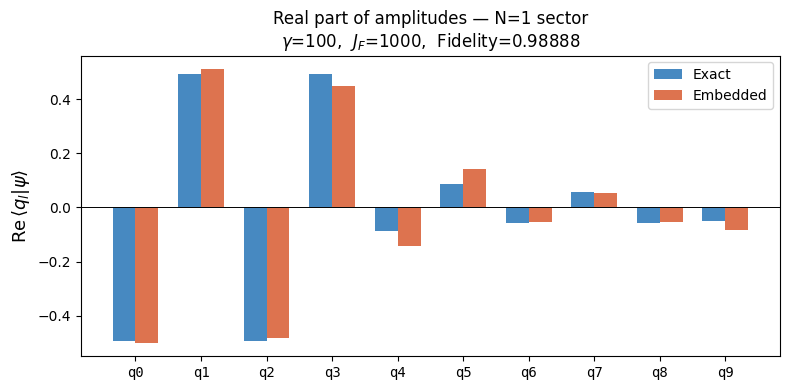

In [207]:
# === Real part only + fidelity (no prenormalization) ===

fidelity = np.abs(np.dot(np.conj(exact_amps), emb_amps)) ** 2
print(f"Fidelity (raw, includes norm loss): {fidelity:.6f}")
print(f"Norm of projected embedded state:   {np.sqrt(np.sum(np.abs(emb_amps)**2)):.6f}")

# --- Plot: real part only ---
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(logical_qubits)
w = 0.35
labels = [f"q{l}" for l in range(logical_qubits)]
CLR_E = "#2775b6"
CLR_M = "#d85a30"

ax.bar(x - w / 2, exact_amps.real, w, color=CLR_E, alpha=0.85, label="Exact")
ax.bar(x + w / 2, emb_amps.real, w, color=CLR_M, alpha=0.85, label="Embedded")
ax.axhline(0, color="k", linewidth=0.7)
ax.set_ylabel(r"$\mathrm{Re}\,\langle q_l|\psi\rangle$", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontfamily="monospace")
ax.legend()
ax.set_title(
    f"Real part of amplitudes — N=1 sector\n"
    f"$\\gamma$={gamma},  $J_F$={J_F},  Fidelity={fidelity:.5f}",
    fontsize=12,
)
plt.tight_layout()
plt.savefig("wavefunction_real.pdf", bbox_inches="tight")
plt.show()

In [208]:
print(np.sum(np.abs(exact_amps) ** 2))  # should be ~1
print(np.sum(np.abs(emb_amps) ** 2))  # how much norm in one-hot sector
print(np.dot(np.conj(exact_amps), emb_amps))  # raw overlap before squaring

1.0000000000000002
0.9983303366432935
(0.9944264071957805+3.2919647630070174e-09j)


In [209]:
for l, chain in chains.items():
    print(f"logical q{l}: chain {chain}, length {len(chain)}")

logical q0: chain [0], length 1
logical q1: chain [1, 2], length 2
logical q2: chain [3], length 1
logical q3: chain [4, 5], length 2
logical q4: chain [6, 7], length 2
logical q5: chain [8], length 1
logical q6: chain [9, 10], length 2
logical q7: chain [11], length 1
logical q8: chain [12, 13], length 2
logical q9: chain [14, 15], length 2


In [28]:
print("inter_edges:", inter_edges)
print("chains:", chains)
for u, v in inter_edges:
    lu = phys_to_logical[u]
    lv = phys_to_logical[v]
    print(f"  edge ({u},{v}): logical ({lu},{lv})")

inter_edges: [(0, 2), (0, 3), (1, 4), (1, 5), (1, 7), (2, 3), (2, 4), (2, 5), (2, 7), (3, 4), (3, 5), (3, 7), (4, 6), (4, 7), (6, 7)]
chains: {0: [0, 1], 1: [2], 2: [3], 3: [4], 4: [5, 6], 5: [7]}
  edge (0,2): logical (0,1)
  edge (0,3): logical (0,2)
  edge (1,4): logical (0,3)
  edge (1,5): logical (0,4)
  edge (1,7): logical (0,5)
  edge (2,3): logical (1,2)
  edge (2,4): logical (1,3)
  edge (2,5): logical (1,4)
  edge (2,7): logical (1,5)
  edge (3,4): logical (2,3)
  edge (3,5): logical (2,4)
  edge (3,7): logical (2,5)
  edge (4,6): logical (3,4)
  edge (4,7): logical (3,5)
  edge (6,7): logical (4,5)
